# 🚀 Crypto Price Prediction Model
### Dataset: Top 50 Cryptocurrency Data (2014–2026)

**What this notebook does:**
- Loads and explores the crypto dataset
- Cleans and prepares the data
- Builds a baseline model using Linear Regression
- Builds an advanced LSTM (Deep Learning) model
- Evaluates and visualizes predictions
- Predicts tomorrow's price!

---
> ✅ Just run each cell top to bottom using **Shift + Enter**

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('✅ All libraries imported!')
print(f'   TensorFlow: {tf.__version__}')

✅ All libraries imported!
   TensorFlow: 2.20.0


## 📂 Step 2: Load the Dataset

In [2]:
# ============================================================
# 🔧 SETTINGS — You can change COIN to any symbol you like!
# ============================================================
FILE_PATH  = 'archive/crypto50_combined.csv'   # Path to the CSV file
COIN       = 'BTC'                              # Coin to predict: 'BTC', 'ETH', 'BNB', etc.
TARGET     = 'Close'                            # Column we want to predict
SEQ_LEN    = 60                                 # How many past days LSTM looks at
# ============================================================

df_raw = pd.read_csv(FILE_PATH)
print(f'✅ Dataset loaded!')
print(f'   Shape  : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'   Columns: {df_raw.columns.tolist()}')
df_raw.head()

✅ Dataset loaded!
   Shape  : 115,072 rows x 8 columns
   Columns: ['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,BTC,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,BTC,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,BTC,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,BTC,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,BTC,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## 🔍 Step 3: Explore the Data

In [3]:
# Check available coins
print('💰 Available coins:')
print(sorted(df_raw['Symbol'].unique()))

💰 Available coins:
['AAVE', 'ADA', 'ALGO', 'APT21794', 'ARB11841', 'ATOM', 'AVAX', 'BCH', 'BNB', 'BONK', 'BTC', 'CRO', 'DAI', 'DOGE', 'DOT', 'ETC', 'ETH', 'FET', 'FIL', 'FLOKI', 'FTM', 'GRT6719', 'HBAR', 'HYPE', 'ICP', 'IMX10603', 'INJ', 'KAS', 'LINK', 'LTC', 'MATIC', 'MKR', 'MNT', 'NEAR', 'PEPE24478', 'RNDR', 'SHIB', 'SOL', 'STX4847', 'SUI20947', 'THETA', 'TON11419', 'TRX', 'UNI7083', 'USDC', 'USDT', 'VET', 'XLM', 'XMR', 'XRP']


In [4]:
# Filter for our chosen coin
df = df_raw[df_raw['Symbol'] == COIN].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'✅ Filtered to {COIN}')
print(f'   Rows      : {len(df):,}')
print(f'   Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

✅ Filtered to BTC
   Rows      : 4,171
   Date range: 2014-09-17 to 2026-02-16


,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,BTC,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,BTC,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,BTC,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,BTC,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,BTC,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


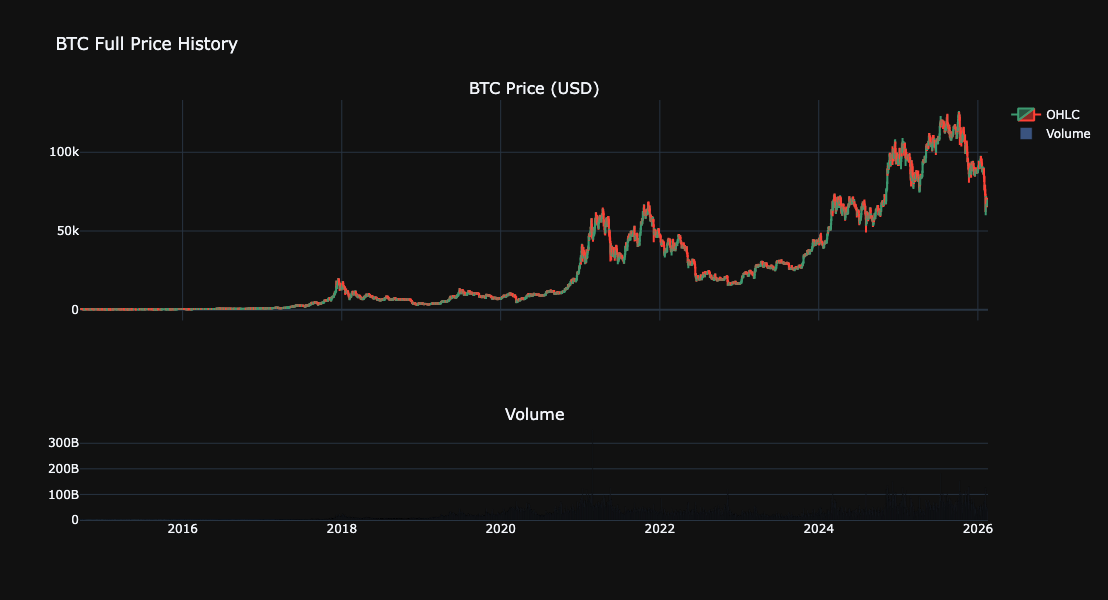

In [5]:
# Interactive Candlestick + Volume chart
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=[f'{COIN} Price (USD)', 'Volume'],
                    row_heights=[0.7, 0.3])

fig.add_trace(go.Candlestick(
    x=df['Date'], open=df['Open'], high=df['High'],
    low=df['Low'], close=df['Close'], name='OHLC'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df['Date'], y=df['Volume'], name='Volume',
    marker_color='rgba(100,149,237,0.5)'
), row=2, col=1)

fig.update_layout(
    title=f'{COIN} Full Price History',
    xaxis_rangeslider_visible=False,
    template='plotly_dark', height=600
)
fig.show()

## 🧹 Step 4: Feature Engineering
We create extra columns (features) that help the model learn patterns better.

In [6]:
# Moving Averages
df['MA_7']  = df['Close'].rolling(7).mean()
df['MA_30'] = df['Close'].rolling(30).mean()
df['MA_90'] = df['Close'].rolling(90).mean()

# Daily Return
df['Daily_Return'] = df['Close'].pct_change() * 100

# Volatility
df['Volatility_7']  = df['Daily_Return'].rolling(7).std()
df['Volatility_30'] = df['Daily_Return'].rolling(30).std()

# Price Range
df['Price_Range'] = df['High'] - df['Low']

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'])

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Features added! Dataset: {len(df):,} rows x {df.shape[1]} columns')
df[['Date','Close','MA_7','MA_30','RSI_14','Daily_Return']].tail()

✅ Features added! Dataset: 4,082 rows x 16 columns


,Date,Close,MA_7,MA_30,RSI_14,Daily_Return
4077,2026-02-12,66221.84375,68890.091518,82158.185547,26.750105,-1.149578
4078,2026-02-13,68857.84375,68647.584821,81222.469401,31.664855,3.980560
4079,2026-02-14,69767.62500,68716.964286,80363.017318,38.050612,1.321246
4080,2026-02-15,68788.18750,68506.030134,79471.786328,38.748514,-1.403857
4081,2026-02-16,68843.15625,68323.512277,78596.560807,35.821093,0.079910


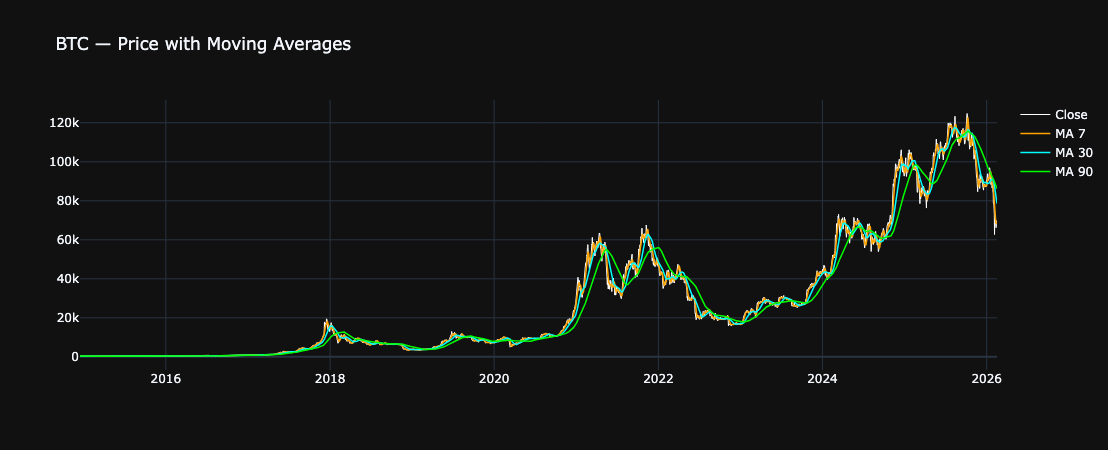

In [7]:
# Plot price with moving averages
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close', line=dict(color='white', width=1)))
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_7'],  name='MA 7',  line=dict(color='orange', width=1.5)))
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_30'], name='MA 30', line=dict(color='cyan',   width=1.5)))
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_90'], name='MA 90', line=dict(color='lime',   width=1.5)))
fig.update_layout(title=f'{COIN} — Price with Moving Averages',
                  template='plotly_dark', height=450)
fig.show()

## 🤖 Step 5: Baseline Model — Linear Regression

In [8]:
FEATURE_COLS = ['Open','High','Low','Volume',
                'MA_7','MA_30','RSI_14',
                'Daily_Return','Volatility_7','Price_Range']

X = df[FEATURE_COLS].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler_X  = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('📊 Linear Regression Results:')
print(f'   MAE  : ${mae_lr:,.2f}')
print(f'   RMSE : ${rmse_lr:,.2f}')
print(f'   R2   : {r2_lr:.4f}')

📊 Linear Regression Results:
   MAE  : $565.17
   RMSE : $771.25
   R2   : 0.9989


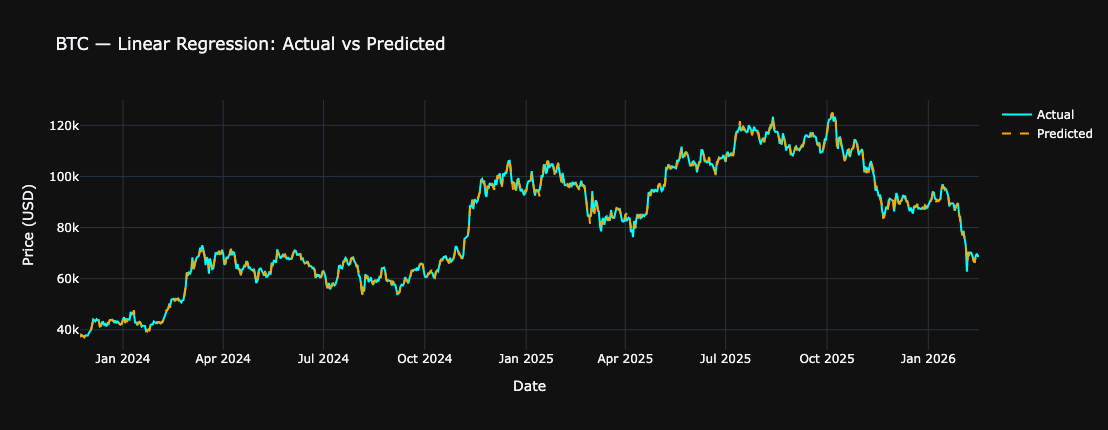

In [9]:
test_dates = df['Date'].values[len(y_train):]

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates, y=y_test,    name='Actual',    line=dict(color='cyan')))
fig.add_trace(go.Scatter(x=test_dates, y=y_pred_lr, name='Predicted', line=dict(color='orange', dash='dash')))
fig.update_layout(title=f'{COIN} — Linear Regression: Actual vs Predicted',
                  xaxis_title='Date', yaxis_title='Price (USD)',
                  template='plotly_dark', height=430)
fig.show()

## 🧠 Step 6: Advanced Model — LSTM (Deep Learning)

In [10]:
close_prices = df[TARGET].values.reshape(-1, 1)
scaler_lstm  = MinMaxScaler()
close_scaled = scaler_lstm.fit_transform(close_prices)

def create_sequences(data, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_len):
        X_seq.append(data[i : i + seq_len])
        y_seq.append(data[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(close_scaled, SEQ_LEN)

split = int(len(X_seq) * 0.8)
X_train_l, X_test_l = X_seq[:split], X_seq[split:]
y_train_l, y_test_l = y_seq[:split], y_seq[split:]

print(f'✅ Sequences ready!')
print(f'   Train: {X_train_l.shape}  |  Test: {X_test_l.shape}')

✅ Sequences ready!
   Train: (3217, 60, 1)  |  Test: (805, 60, 1)


In [11]:
tf.random.set_seed(42)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('✅ Training complete!')

Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0028 - val_loss: 3.9137e-04
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.4598e-04 - val_loss: 3.4116e-04
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4253e-04 - val_loss: 8.1670e-04
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.3096e-04 - val_loss: 1.8431e-04
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3583e-04 - val_loss: 4.0175e-04
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4324e-04 - val_loss: 1.5225e-04
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.0086e-04 - val_loss: 1.6432e-04
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.5827e-04 - val_loss: 1.9475e-04
Epoch 9/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.3119e-04 - val_loss: 2.3854e-04
Epoch 10/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7712e-04 - val_loss: 2.0267e-04
Epoch 11/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.

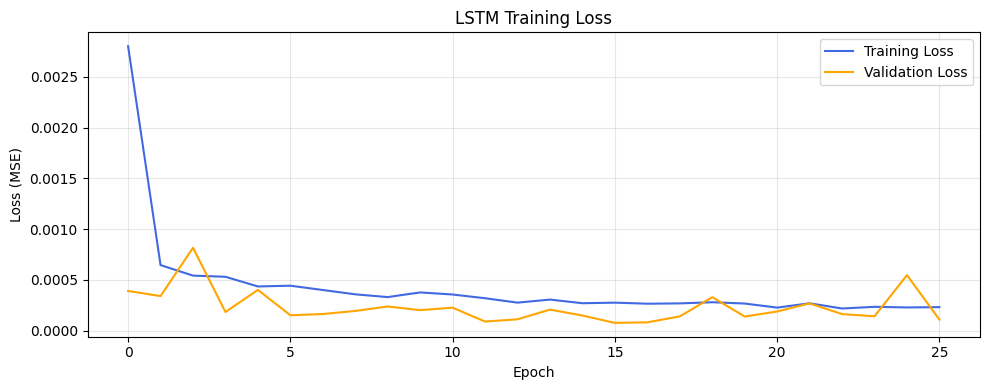

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Training Loss',   color='royalblue')
ax.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax.set_title('LSTM Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
y_pred_scaled = model.predict(X_test_l)
y_pred_lstm   = scaler_lstm.inverse_transform(y_pred_scaled)
y_actual      = scaler_lstm.inverse_transform(y_test_l)

mae_lstm  = mean_absolute_error(y_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
r2_lstm   = r2_score(y_actual, y_pred_lstm)

print('📊 LSTM Results:')
print(f'   MAE  : ${mae_lstm:,.2f}')
print(f'   RMSE : ${rmse_lstm:,.2f}')
print(f'   R2   : {r2_lstm:.4f}')

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
📊 LSTM Results:
   MAE  : $5,814.06
   RMSE : $6,903.13
   R2   : 0.9065


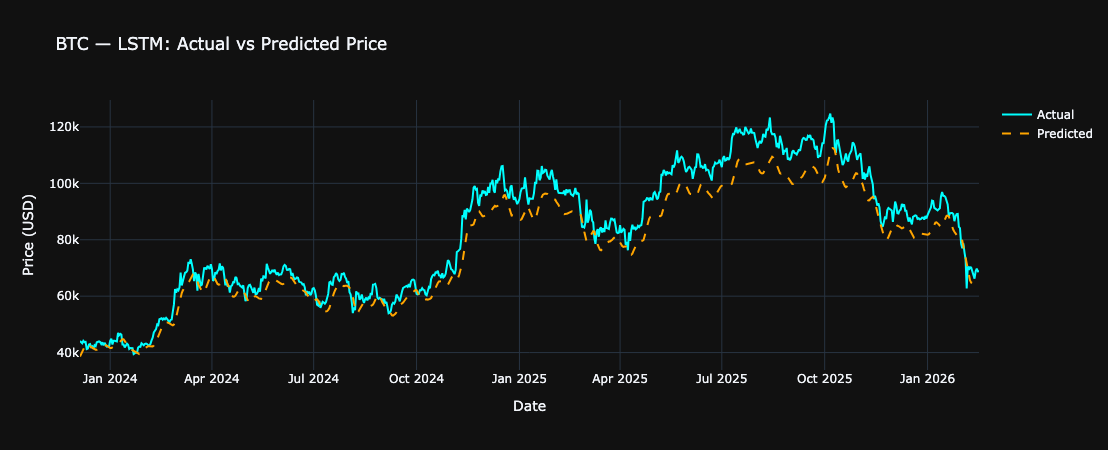

In [15]:
lstm_dates = df['Date'].values[SEQ_LEN + split:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=lstm_dates, y=y_actual.flatten(),    name='Actual',    line=dict(color='cyan',   width=2)))
fig.add_trace(go.Scatter(x=lstm_dates, y=y_pred_lstm.flatten(), name='Predicted', line=dict(color='orange', width=2, dash='dash')))
fig.update_layout(
    title=f'{COIN} — LSTM: Actual vs Predicted Price',
    xaxis_title='Date', yaxis_title='Price (USD)',
    template='plotly_dark', height=450
)
fig.show()

## 📊 Step 7: Compare Both Models

In [16]:
results = pd.DataFrame({
    'Model'    : ['Linear Regression', 'LSTM (Deep Learning)'],
    'MAE ($)'  : [round(mae_lr, 2),    round(mae_lstm, 2)],
    'RMSE ($)' : [round(rmse_lr, 2),   round(rmse_lstm, 2)],
    'R2 Score' : [round(r2_lr, 4),     round(r2_lstm, 4)],
})
print('Lower MAE/RMSE = better | Higher R2 = better')
results

Lower MAE/RMSE = better | Higher R2 = better


,Model,MAE ($),RMSE ($),R2 Score
0,Linear Regression,565.17,771.25,0.9989
1,LSTM (Deep Learning),5814.06,6903.13,0.9065


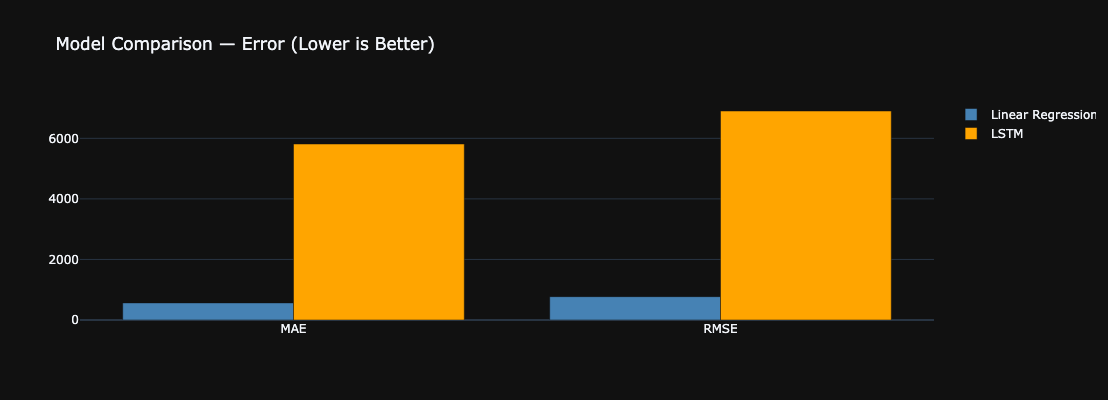

In [17]:
fig = go.Figure(data=[
    go.Bar(name='Linear Regression', x=['MAE','RMSE'], y=[mae_lr,  rmse_lr],  marker_color='steelblue'),
    go.Bar(name='LSTM',              x=['MAE','RMSE'], y=[mae_lstm,rmse_lstm], marker_color='orange'),
])
fig.update_layout(title='Model Comparison — Error (Lower is Better)',
                  barmode='group', template='plotly_dark', height=400)
fig.show()

## 🔮 Step 8: Predict Tomorrow's Price!

In [18]:
last_60_days   = close_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
pred_scaled    = model.predict(last_60_days, verbose=0)
tomorrow_price = scaler_lstm.inverse_transform(pred_scaled)[0][0]

last_close = df['Close'].iloc[-1]
change_pct = ((tomorrow_price - last_close) / last_close) * 100
direction  = '📈 UP' if change_pct > 0 else '📉 DOWN'

print('=' * 50)
print(f'  🔮 {COIN} Price Prediction for Tomorrow')
print('=' * 50)
print(f'  Last Close Price  : ${last_close:>12,.2f}')
print(f'  Predicted Price   : ${tomorrow_price:>12,.2f}')
print(f'  Expected Change   : {change_pct:>+.2f}%  {direction}')
print('=' * 50)
print()
print('  Educational purposes only — NOT financial advice!')

  🔮 BTC Price Prediction for Tomorrow
  Last Close Price  : $   68,843.16
  Predicted Price   : $   65,362.62
  Expected Change   : -5.06%  📉 DOWN

  Educational purposes only — NOT financial advice!


## 💾 Step 9: Save the Model

In [19]:
model.save(f'{COIN}_lstm_model.keras')
print(f'✅ Model saved as {COIN}_lstm_model.keras')

✅ Model saved as BTC_lstm_model.keras


---
## 🎓 You built a Crypto Price Prediction model from scratch!

**Next ideas:**
- Change `COIN = 'ETH'` to predict other coins
- Try `SEQ_LEN = 90` for longer memory
- Build a Streamlit web app to share your model!

---
*Educational purposes only. Never invest based on model predictions alone.*